In [252]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import shutil
from sensor_fusion import kalman_filters, height
from collections import deque

from .globals import *
from .utils import *
from .analyse_journey import analyse_journey

In [253]:
import configparser

# Initialize the parser
config = configparser.ConfigParser()

# Read the config file
config.read('config.ini')

FREQUENCY = config['data-collection'].getint('frequency')

ACCELEROMETER_VARIANCE = config['measurements'].getfloat('accelerometer_variance')

STAGE_NO_CHANGE_THRESHOLD = config['data-analysis'].getfloat('stage_no_change_threshold')
STAGE_ROLLING_AVG_LEN = config['data-analysis'].getint('stage_rolling_avg_len')

VELOCITY_PULL_TO_ZERO = config['data-analysis'].getfloat('velocity_pull_to_zero')

ACCELEROMETER_DRIFT_CORRECTION_BOUND = config['data-analysis'].getfloat('accelerometer_drift_correction')
BAROMETER_DRIFT_CORRECTION_BOUND = config['data-analysis'].getfloat('barometer_drift_correction')

MIN_FLOOR_SPACING = config['data-analysis'].getfloat('min_floor_spacing')

In [255]:
# def load_data(path):
#     """
#     Loads the the data into a dataframe
#     @params
#     path: where the data to analyse is
#     """
#     df = pd.read_csv(path)

#     if df[TIMESTAMPS].iloc[0] > 0:
#         df[TIMESTAMPS] = (df[TIMESTAMPS] - df['timestamp'].iloc[0]) / 1000
    
#     df['raw_acceleration'] = df['acceleration']
    
#     return df

We will only work with the df['acc'] column as this will allow us to change it to just acc_z in the future if need be

In [256]:
def save_df(df, path, number):
    """
    Saves the dataframe
    @params
    df: dataframe
    path: the path to save the df to
    name: 
    """
    os.makedirs(path, exist_ok=True)
    df.to_csv(f"{path}/{number}.csv", index=False)

In [257]:
def drift_correction(df, col, bound):
    """
    Removes the offset on the acceleration
    @params
    df: dataframe
    bound: how much the function will accept a lack of significant movement
    """
    rolling_sum = 0
    num_of_pnts = 0
    for acc in df[col]:
        if acc == df[col].iloc[0] or abs(rolling_sum / num_of_pnts - acc) < bound:
            rolling_sum += acc
            num_of_pnts += 1
    df.loc[0:len(df), [col]] -= rolling_sum / num_of_pnts


In [258]:
def correct_vel_at_stationary(df, effect):
    """
    When stage == 0, reduce velocity to 0 by effect
    @params
    df: dataframe
    col: column name
    effect: how much to reduce at each timestep
    """
    assert "stages" in df.columns, "stages needs to be in the dataframe"
    assert MODEL_VELOCITY in df.columns, f"{MODEL_VELOCITY} needs to be in the dataframe"
    for i in range(len(df)):

        if df['stages'].iloc[i] == 0:
            if df[MODEL_VELOCITY].iloc[i] > effect:
                df.loc[i:, [MODEL_VELOCITY]] = df.loc[i:, [MODEL_VELOCITY]] - effect
            elif df[MODEL_VELOCITY].iloc[i] < - effect:
                df.loc[i:, [MODEL_VELOCITY]] = df.loc[i:, [MODEL_VELOCITY]] + effect
                    

In [259]:
def barometer_height_snap_to_floor(df, min_floor_spacing):
    assert STAGES in df.columns, f"{STAGES} needs to be in the dataframe"
    df[BAROMETER_LEVELS] = pd.NA

    floors = [0]

    i = 0
    while i < len(df):
        height_data = []
        while i < len(df) and (not len(height_data) or df[STAGES].iloc[i] == 0):
            if df[STAGES].iloc[i] == 0: height_data.append(df[BAROMETER_HEIGHT].iloc[i])
            i += 1

        if (len(height_data) <= 4): continue

        np_floors = np.array(floors)
        height_data = np.array(height_data)
        height_data = height_data[int(len(height_data) * 0.25):int(len(height_data) * 0.75)]
        height = np.mean(height_data)
        floor_height_differences = np_floors - height
        abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))

        if abs_min_floor_height_dif < min_floor_spacing / 2:
            abs_min_index = np.argmin(np.abs(floor_height_differences) - abs_min_floor_height_dif)
            df.loc[i - len(height_data):, [BAROMETER_HEIGHT]] = df.loc[i - len(height_data):, [BAROMETER_HEIGHT]] + floor_height_differences[abs_min_index]

            df.loc[i - len(height_data):i, [BAROMETER_LEVELS]] = np_floors[abs_min_index]

        else:
            floors.append(float(height))
            df.loc[i - len(height_data):i, [BAROMETER_LEVELS]] = float(height)
            
    return floors
        
    

In [260]:
def get_floor_journey(delta_heights):

    # Assume calibration (0 -> top)
    i = 0
    floors = [0]
    while i < len(delta_heights) and delta_heights[i] > 0: 
        floors.append(delta_heights[i] + floors[-1])
        i += 1
        
    floors = np.array(floors)
    journey = [*range(len(floors))]
    for dh in delta_heights[i:]:
        new_height = floors[journey[-1]] + dh
        journey.append(np.argmin(np.abs(floors - new_height)))
        
    return journey

In [263]:
def linear_offset(df, label, offset, start, stop):
    """
    time-dependent correction or transformation of the label values,
    with the offset controlling how much change happens across the time range
    @params
    df: dataframe
    label: column name to edit
    offset: 
    start: 
    stop: 
    """
    dt = df[TIMESTAMPS].iloc[stop] - df[TIMESTAMPS].iloc[start]
    for i in range(start, stop + 1):
        df.at[i, label] = df[label].iloc[i] - offset * ((df[TIMESTAMPS].iloc[i] - df[TIMESTAMPS].iloc[start]) / dt)
    
# def linear_offset_avoid_stationary(df, label, offset, start, stop):
#     """
#     time-dependent correction or transformation of the label values,
#     with the offset controlling how much change happens across the time range
#     @params
#     df: dataframe
#     label: column name to edit
#     offset: 
#     start: 
#     stop: 
#     """
#     moving_time = 0
#     cumulative_moving_time = {}  # Maps index to cumulative moving time
#     last_timestamp = df[TIMESTAMPS].iloc[start]
#     current_moving_time = 0
    
#     for i in range(start + 1, stop + 1):
#         current_dt = df[TIMESTAMPS].iloc[i] - last_timestamp
        
#         # If we're moving (not stationary), add to our moving time
#         if df[STAGES].iloc[i] != 0:
#             moving_time += current_dt
#             current_moving_time += current_dt
            
#         # Store the cumulative moving time up to this point
#         cumulative_moving_time[i] = current_moving_time
#         last_timestamp = df[TIMESTAMPS].iloc[i]
    
#     # If we have no moving time, avoid division by zero
#     if moving_time == 0:
#         return
        
#     # Second pass: apply corrections based on moving time only
#     last_valid_i = start
#     for i in range(start, stop + 1):
#         if df[STAGES].iloc[i] != 0:  # Only modify non-stationary points
#             # Calculate what fraction of moving time has passed
#             last_valid_i = i
#             time_fraction = cumulative_moving_time.get(i, 0) / moving_time
#             # Apply proportional correction
#             df.at[i, label] = df[label].iloc[i] - (offset * time_fraction)
#         else:
#             time_fraction = cumulative_moving_time.get(last_valid_i, 0) / moving_time
#             # Apply proportional correction
#             df.at[i, label] = df[label].iloc[i] - (offset * time_fraction)

In [264]:
def correct_vel_at_constant(df):

    # Makes velocity constant at stages 0, 2

    i = 0
    direction = 0
    journey_start = 0
    while i < len(df):
        
        if df[STAGES].iloc[i] == 1:
            direction = sign(df[MODEL_VELOCITY].iloc[i])

        if df[STAGES].iloc[i] in [2, 3] and sign(df[MODEL_VELOCITY].iloc[i]) != direction:

            offset = None

            while df[STAGES].iloc[i] in [2, 3] and sign(df[MODEL_VELOCITY].iloc[i]) != direction:
                offset = df[MODEL_VELOCITY].iloc[i] if offset == None or abs(df[MODEL_VELOCITY].iloc[i]) > abs(offset) else offset
                i += 1
            
            linear_offset(df, MODEL_VELOCITY, offset, journey_start, i)
            df.loc[i + 1:, [MODEL_VELOCITY]] -= offset
        
        if df[STAGES].iloc[i] == 0:
            journey_start = i
        
        i += 1

def correct_vel_to_go_back_to_zero(df):
    i = 1
    previous_journey = 0
    while i < len(df):
        start = i
        stop = i

        while i < len(df) - 1 and df[STAGES].iloc[i] in [0, 2]:
            stop += 1
            i += 1
        
        if start != stop:
            if df[STAGES].iloc[i - 1] == 0:
                offset = df[MODEL_VELOCITY].iloc[stop] / 2
                linear_offset(df, MODEL_VELOCITY, offset, previous_journey, start)
                df.loc[start + 1:, [MODEL_VELOCITY]] -= offset
            else:
                offset = df[MODEL_VELOCITY].iloc[stop] - df[MODEL_VELOCITY].iloc[start]
                linear_offset(df, MODEL_VELOCITY, offset, start, stop)
                df.loc[stop + 1:, [MODEL_VELOCITY]] -= offset

        if df[STAGES].iloc[i - 1] == 0 and df[STAGES].iloc[i] == 1:
            previous_journey = i
        i += 1

In [265]:
def correct_height_at_stationary(df, height_label):
    i = 0
    while i < len(df):
        start = i
        stop = i

        while i < len(df) - 1 and df[STAGES].iloc[i] == 0:
            stop += 1
            i += 1
        
        if start != stop:
            offset = df[height_label].iloc[stop] - df[height_label].iloc[start]
            linear_offset(df, height_label, offset, start, stop)
            df.loc[stop + 1:, [height_label]] -= offset
        i += 1

def correct_height_from_barometer_levels(df, height_label):
    i = 1
    while i < len(df):

        journeys_checked = 0

        j = i - 1
        if df[STAGES].iloc[j] == 0 and df[STAGES].iloc[i] == 1:
            
            curr_level = df[BAROMETER_LEVELS].iloc[j]
            stationary_start = None
            previous_journey = None

            while j > 1 and journeys_checked < 6:

                if previous_journey == None and df[STAGES].iloc[j - 1] == 0 and df[STAGES].iloc[j] == 1:
                    previous_journey = j

                if stationary_start == None and df[STAGES].iloc[j - 1] == 3 and df[STAGES].iloc[j] == 0:
                    stationary_start = j

                if df[STAGES].iloc[j - 1] == 0 and df[STAGES].iloc[j] == 1:

                    if df[BAROMETER_LEVELS].iloc[j - 1] == curr_level:

                        k = j - 1
                        cum_sum = 0
                        while k > 0 and df[STAGES].iloc[k] == 0:
                            cum_sum += df[height_label].iloc[k]
                            k -= 1

                        offset = df[height_label].iloc[(stationary_start + i) // 2] - (cum_sum / (j - 1 - k))
                        linear_offset(df, height_label, offset, previous_journey, stationary_start)
                        df.loc[stationary_start + 1:, [height_label]] -= offset
                        break
                    journeys_checked += 1

                j -= 1

        i += 1

In [266]:
def get_dist(df, col, start, end):
    """
    Gets mean and variance of sample of col in df from start to end
    @params
    df: dataframe
    col: column name
    start: beginning of calculation
    end: end of calculation
    """
    mean = df.loc[start:end, col].mean()
    var_sum = 0
    for i in range(start, end):
        var_sum += (df[col].iloc[i] - mean) ** 2
    return mean, var_sum / (end - start - 1)

In [267]:
def get_stages(df, maxlen=20, mean_threshold=0.05, variance_threshold=0.0001, buffer_seconds=5):
    """
    Updates the STAGES column based on changes in rolling mean and variance of ACCELERATION.

    Args:
        df (pd.DataFrame): The DataFrame containing the ACCELERATION and TIMESTAMP columns.
        maxlen (int): Window size for rolling mean and variance calculations.
        mean_threshold (float): Threshold for the rolling mean.
        variance_threshold (float): Threshold for the variance.
        buffer_seconds (float): Minimum time (in seconds) of inactivity before transitioning from stage 1 -> 0.

    Returns:
        pd.DataFrame: The updated DataFrame with the STAGES column.
    """

    peak = None
    peak_sign = None
    min_peak = 0.1
    cycle_complete = False

    dt = df[TIMESTAMPS].iloc[1] - df[TIMESTAMPS].iloc[0]
    dt_count = buffer_seconds // dt

    # Initialize rolling window
    rolling_window = deque(maxlen=maxlen)
    df[STAGES] = 0  # Initialize STAGES column

    # Initialize stage and time tracking
    curr_stage = 0
    last_activity = df[TIMESTAMPS].iloc[0]  # Initialize last activity timestamp

    for i in range(len(df)):
        # Add current acceleration to the rolling window
        rolling_window.append(df[ACCELERATION].iloc[i])
        
        if len(rolling_window) < maxlen:
            continue  # Skip until the rolling window is full
        
        # Calculate rolling mean and variance
        rolling_mean = np.mean(rolling_window)
        rolling_variance = np.var(rolling_window)
        
        # Handle transitions
        if curr_stage == 0:
            if abs(rolling_mean) > mean_threshold or rolling_variance > variance_threshold:
                curr_stage = 1
                df.loc[max(i - (dt_count // 2), 0):, STAGES] = curr_stage
                last_activity = df[TIMESTAMPS].iloc[i]  # Update the last activity timestamp

                peak = None
                peak_sign = None
                cycle_complete = False

        elif curr_stage == 1:

            if min_peak < abs(df[ACCELERATION].iloc[i]):
                if peak == None:
                    peak = abs(df[ACCELERATION].iloc[i])
                    peak_sign = sign(df[ACCELERATION].iloc[i])
                elif abs(peak) > abs(df[ACCELERATION].iloc[i]) and sign(df[ACCELERATION].iloc[i]) == peak_sign:
                    peak = abs(df[ACCELERATION].iloc[i])
                elif peak_sign != sign(df[ACCELERATION].iloc[i]):
                    cycle_complete = True


            if abs(rolling_mean) <= mean_threshold and rolling_variance <= variance_threshold and cycle_complete:

                time_since_last_activity = df[TIMESTAMPS].iloc[i] - last_activity
                if time_since_last_activity > buffer_seconds:
                    curr_stage = 0
                    df.loc[max(i - maxlen, 0):, STAGES] = curr_stage
            else:
                last_activity = df[TIMESTAMPS].iloc[i]  # Update the last activity timestamp
        
        df.loc[i, STAGES] = curr_stage

    return df


In [268]:
def split_dataframe_by_stages(df, buffer):
    """
    Splits a DataFrame into sections based on changes in the stages column,
    separating sections by 000000 and adding a buffer of zeros on each side.

    Args:
        df (pd.DataFrame): The DataFrame containing the stages column.
        buffer (int): The number of consecutive zeros to include as a buffer.
        stages_col (str): The name of the stages column in the DataFrame.

    Returns:
        list: A list of DataFrames, each representing a section of the original DataFrame.
    """
    sections = []
    indexes = []
    in_section = False
    start_index = None

    for i in range(len(df)):
        if df[STAGES].iloc[i] != 0 and not in_section:
            # Start of a new section
            in_section = True
            start_index = max(0, i - buffer)  # Add buffer before the section
        elif df[STAGES].iloc[i] == 0 and in_section:
            # End of a section
            in_section = False
            end_index = min(len(df), i + buffer)  # Add buffer after the section
            sections.append(df.iloc[start_index:end_index])
            indexes.append(end_index)

    return sections, indexes

In [271]:


# save_dir = "./analysed/"

# for item in os.listdir(save_dir):
#     item_path = os.path.join(save_dir, item)
#     if os.path.isfile(item_path) or os.path.islink(item_path):
#         os.remove(item_path)
#     elif os.path.isdir(item_path):
#         shutil.rmtree(item_path)

# datastreams = "./datastreams"
# folders = os.listdir(datastreams)
# dtype = [('timestamp', 'int32'), ('acceleration', 'float32'), ('pressure', 'float32')]
# FREQUENCY = 10
# data_size_from_mins = lambda mins : int(FREQUENCY * 60 * mins)
# data_shape = (data_size_from_mins(10),)
# increment = 5

# for folder in folders:
#     path = f"{datastreams}/{folder}"
#     curr_data = []
#     journey = 0
#     data_file = 0
#     while data_file < len(os.listdir(path)):
#         data_path = f"{path}/{data_file}.dat"
#         prev_data_file = data_file
#         data = np.memmap(data_path, dtype=dtype, mode='r', shape=data_shape)
#         start = 0
#         end = increment

#         while end <= data_shape[0]:
#             if data_file != prev_data_file:
#                 prev_data_file = data_file
#                 data_path = f"{path}/{data_file}.dat"
#                 data = np.memmap(data_file, dtype=dtype, mode='r', shape=data_shape)

#             curr_data.extend(data[start:end])
#             df = pd.DataFrame(np.array(curr_data, dtype=dtype), columns=['timestamp', 'acceleration'])
#             df['raw_acceleration'] = df['acceleration']
#             df['timestamp'] -= df['timestamp'].iloc[0]

#             # var_a = (acc_smooth * var_raw_acc) / (2 + acc_smooth)
#             smooth(df, 'acceleration', ACCELERATION_SMOOTHING)
#             drift_correction(df, bound=0.02)

#             add_stages(df, LOWER_ACC_THRESHOLD, UPPER_ACC_THRESHOLD, 'acceleration', 'a')

#             first_one_index = df[df['aStages'] == 1].index.min()
#             if df['aStages'].iloc[-1] != 1 or not pd.notna(first_one_index):
#                 end += increment
#                 start += increment
#                 continue

#             df_slice = df.iloc[first_one_index + 1:]
#             zeros_after = df_slice[df_slice['aStages'] == 0]
#             if not zeros_after.empty:
#                 zero_after_one_index = zeros_after.index.min()

#             if zeros_after.empty or not pd.notna(zero_after_one_index):
#                 end += increment
#                 start += increment
#                 continue
            
#             print("Journey found!")
#             # Found the journey
#             half_stationary = (len(df) - zero_after_one_index) // 2

#             df = df[:-half_stationary]
#             if half_stationary > end:
#                 data_file -= 1
            
#             end = (end - half_stationary) % data_shape[0]
#             start = (start - half_stationary) % data_shape[0]

#             curr_data.clear()
#             start = end
#             end += min(increment, data_shape[0] - end)

#             mean, acc_var = get_dist(df, 'raw_acceleration', 0, df[df['aStages'] == 1].index[0])

#             differentiate(df, 'acceleration', 'timestamp', 'jerk')

#             #velocity variance = Sum 0...n: ((dt ** 2) / 2) * acc_var
#             integrate(df, 'acceleration', 'timestamp', 'model_velocity')

#             # Velocity variance resets to 0 at each stationary location
#             correct_vel_at_stationary(df, 'model_velocity', 0.0005)

#             # Height variance = Sum 0...n: ((dt ** 2) / 2) * velocity variance
#             integrate(df, 'model_velocity', 'timestamp', 'model_height')
            
#             # get_true_values(df, acc_var, 0)
                
#             save_df(df, save_dir + folder, journey)
#             journey += 1
        
#         data_file += 1


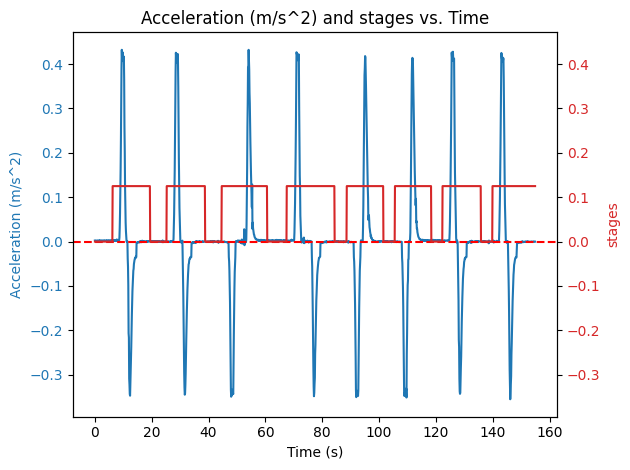

Based on Barometer:
0 -> 1 -> 2 -> 0 -> 2 -> 1 -> 0 -> 1
Based on Accelerometer:
0 -> 1 -> 2 -> 0 -> 2 -> 1 -> 0 -> 1
Based on sensor fusion of Barometer and Accelerometer:
0 -> 1 -> 2 -> 0 -> 2 -> 1 -> 0 -> 1


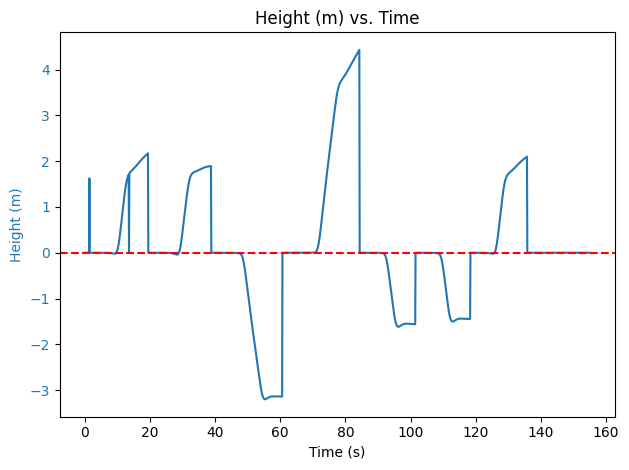

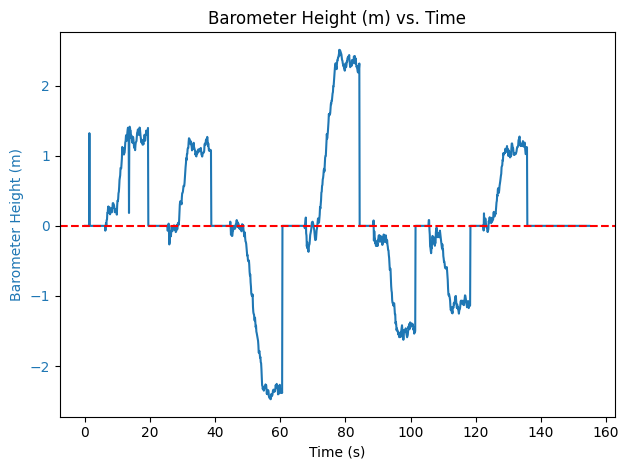

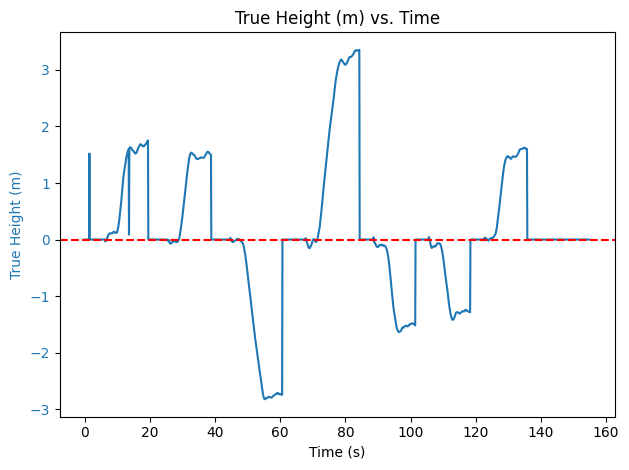

In [273]:
def main():
    save_dir = "./analysed/"

    for item in os.listdir(save_dir):
        item_path = os.path.join(save_dir, item)
        if os.path.isfile(item_path) or os.path.islink(item_path):
            os.remove(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)

    datastreams = "./datastreams"
    folder = os.listdir(datastreams)[1]
    dtype = [('timestamp', 'int32'), ('acceleration', 'float32'), ('pressure', 'float32')]
    data_size_from_mins = lambda mins : int(FREQUENCY * 60 * mins)
    data_shape = (data_size_from_mins(10),)

    data_path = f"{datastreams}/{folder}/0.dat"
    data = np.memmap(data_path, dtype=dtype, mode='r', shape=data_shape)[:1500]

    df = pd.DataFrame(data, columns=['timestamp', 'acceleration', 'pressure'])

    # Correct timestamps
    df = df[df[TIMESTAMPS] != 0]
    df.reset_index(drop=True, inplace=True)
    df[TIMESTAMPS] -= df[TIMESTAMPS].iloc[0]
    df[TIMESTAMPS] /= 1000

    df.loc[0:len(df), [MODEL_DISPLACEMENT]] = 0
    df.loc[0:len(df), [MODEL_VELOCITY]] = 0
    df.loc[0:len(df), [BAROMETER_HEIGHT]] = 0
    df.loc[0:len(df), [TRUE_DISPLACEMENT]] = 0
    df.loc[0:len(df), [TRUE_VELOCITY]] = 0

    
    # Get initial stages

    # drift_correction(df, ACCELERATION, bound=ACCELEROMETER_DRIFT_CORRECTION_BOUND)
    df[ACCELERATION] -= df[ACCELERATION].mode().mean()
    # smooth_kalman(df, ACCELERATION, ACCELEROMETER_VARIANCE)

    # integrate(df, ACCELERATION, TIMESTAMPS, MODEL_VELOCITY)
    
    get_stages(df, maxlen=15, mean_threshold=0.02, variance_threshold=0.00005, buffer_seconds=5)

    first_journey = df[df[STAGES] == 1].index[0]
    _, acc_var = get_dist(df, ACCELERATION, 0, first_journey)

    df[STAGES] /= 8
    chart(df, ACCELERATION, STAGES)
    df[STAGES] *= 8

    journeys, journey_end_index = split_dataframe_by_stages(df, 0)
    for journey in journeys:
        journey.reset_index(drop=True, inplace=True)

        analyse_journey(journey)
        
        df.update(journey.set_index(TIMESTAMPS))

    print("Based on Barometer:")
    delta_heights = []
    for i in journey_end_index:
        delta_heights.append(df[BAROMETER_HEIGHT].iloc[i - 1])

    floor_journey = get_floor_journey(delta_heights)
    print(' -> '.join([str(i) for i in floor_journey]))

    print("Based on Accelerometer:")
    delta_heights = []
    for i in journey_end_index:
        delta_heights.append(df[MODEL_DISPLACEMENT].iloc[i - 1])

    floor_journey = get_floor_journey(delta_heights)
    print(' -> '.join([str(i) for i in floor_journey]))

    print("Based on sensor fusion of Barometer and Accelerometer:")
    delta_heights = []
    for i in journey_end_index:
        delta_heights.append(df[TRUE_DISPLACEMENT].iloc[i - 1])

    floor_journey = get_floor_journey(delta_heights)
    print(' -> '.join([str(i) for i in floor_journey]))

    # for i in journey_end_index[::-1]:
    #     df.loc[i:, [MODEL_DISPLACEMENT]] += df[MODEL_DISPLACEMENT].iloc[i - 1]
    #     df.loc[i:, [BAROMETER_HEIGHT]] += df[BAROMETER_HEIGHT].iloc[i - 1]

    chart(df, MODEL_DISPLACEMENT)
    chart(df, BAROMETER_HEIGHT)
    chart(df, TRUE_DISPLACEMENT)
            
    save_df(df, save_dir + folder, "bob")
main()


In [274]:
# correct_height_at_stationary(df, TRUE_DISPLACEMENT)
# correct_height_from_barometer_levels(df, TRUE_DISPLACEMENT)
# df = df[400:750]
# chart(MODEL_DISPLACEMENT)
# # chart(TRUE_VELOCITY)

# # chart(MODEL_VELOCITY)

# chart(TRUE_DISPLACEMENT)
# chart(BAROMETER_HEIGHT)


In [275]:
# chart(MODEL_VELOCITY)
# chart(TRUE_VELOCITY)

In [276]:
# chart(ACCELERATION)